In [ ]:
"""
=============================================================================
SAM PAPER DETECTION PIPELINE - COMPLETE WITH PERSPECTIVE CORRECTION
=============================================================================
Enhanced with:
- Geometric filtering for robust paper detection
- Perspective correction to unwarp tilted/angled photos
- Proper processing order to match dataset images
- No padding, no stretching - direct resize to 512×362

INSTALLATION:
    uv pip install segment-anything

=============================================================================
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import urllib.request
from pathlib import Path
from typing import List, Dict, Tuple, Optional

In [ ]:
# =============================================================================
# GEOMETRIC FILTERING FUNCTIONS
# =============================================================================

def is_paper_like(mask: np.ndarray, img_shape: Tuple[int, int],
                  min_area_ratio: float = 0.05,
                  max_area_ratio: float = 0.85,
                  min_aspect_ratio: float = 0.5,
                  max_aspect_ratio: float = 2.5,
                  min_rectangularity: float = 0.7) -> Tuple[bool, Dict]:
    """
    Check if a mask represents a paper-like object based on geometric properties
    """
    img_area = img_shape[0] * img_shape[1]

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return False, {"reason": "no_contours"}

    contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(contour)

    # Area check
    area_ratio = area / img_area
    if area_ratio < min_area_ratio:
        return False, {"reason": "too_small", "area_ratio": area_ratio}
    if area_ratio > max_area_ratio:
        return False, {"reason": "too_large_likely_background", "area_ratio": area_ratio}

    # Aspect ratio check
    rect = cv2.minAreaRect(contour)
    width, height = rect[1]

    if width == 0 or height == 0:
        return False, {"reason": "degenerate_shape"}

    aspect_ratio = max(width, height) / min(width, height)
    if aspect_ratio < min_aspect_ratio or aspect_ratio > max_aspect_ratio:
        return False, {"reason": "bad_aspect_ratio", "aspect_ratio": aspect_ratio}

    # Rectangularity check
    bbox_area = width * height
    rectangularity = area / bbox_area if bbox_area > 0 else 0
    if rectangularity < min_rectangularity:
        return False, {"reason": "not_rectangular", "rectangularity": rectangularity}

    # Corner count check
    epsilon = 0.02 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    num_corners = len(approx)
    if num_corners < 4 or num_corners > 8:
        return False, {"reason": "wrong_corner_count", "num_corners": num_corners}

    # Convexity check
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0
    if solidity < 0.8:
        return False, {"reason": "not_convex", "solidity": solidity}

    metrics = {
        "reason": "PAPER_DETECTED",
        "area_ratio": area_ratio,
        "aspect_ratio": aspect_ratio,
        "rectangularity": rectangularity,
        "num_corners": num_corners,
        "solidity": solidity,
        "area_pixels": int(area),
        "score": (rectangularity + solidity) / 2
    }

    return True, metrics

In [ ]:
def find_best_paper_mask(all_masks: List[Dict], img_shape: Tuple[int, int],
                         verbose: bool = True) -> Tuple[Optional[np.ndarray], Dict]:
    """
    Find the best paper candidate from all SAM masks using geometric filtering
    """
    if verbose:
        print(f"\n🔍 Analyzing {len(all_masks)} detected objects...")
        print(f"   Image size: {img_shape[1]}×{img_shape[0]} pixels")

    paper_candidates = []

    for i, mask_dict in enumerate(all_masks):
        mask = (mask_dict['segmentation'].astype(np.uint8)) * 255
        is_paper, metrics = is_paper_like(mask, img_shape)

        if is_paper:
            paper_candidates.append({
                'index': i,
                'mask': mask,
                'metrics': metrics,
                'sam_area': mask_dict['area']
            })

            if verbose:
                print(f"   ✓ Object {i+1}: PAPER CANDIDATE")
                print(f"      Score: {metrics['score']:.3f} | Area: {metrics['area_ratio']:.1%} | Corners: {metrics['num_corners']}")
        else:
            if verbose:
                reason = metrics.get('reason', 'unknown')
                print(f"   ✗ Object {i+1}: Rejected - {reason}")

    if not paper_candidates:
        if verbose:
            print("\nNo paper-like objects found!")
        return None, {}

    paper_candidates.sort(key=lambda x: x['metrics']['score'], reverse=True)
    best = paper_candidates[0]

    if verbose:
        print(f"\nSelected best paper: Object {best['index']+1} (score: {best['metrics']['score']:.3f})")

    return best['mask'], best['metrics']

In [ ]:
# =============================================================================
# PERSPECTIVE CORRECTION FUNCTIONS
# =============================================================================

def order_corners(corners: np.ndarray) -> np.ndarray:
    """
    Order corners as: [top-left, top-right, bottom-right, bottom-left]

    Args:
        corners: Array of 4 corner points

    Returns:
        Ordered corners array
    """
    # Reshape if needed
    corners = corners.reshape(4, 2)

    # Initialize ordered array
    ordered = np.zeros((4, 2), dtype=np.float32)

    # Sum of coordinates: top-left has smallest sum, bottom-right has largest
    s = corners.sum(axis=1)
    ordered[0] = corners[np.argmin(s)]  # top-left
    ordered[2] = corners[np.argmax(s)]  # bottom-right

    # Difference: top-right has smallest diff (x-y), bottom-left has largest
    diff = np.diff(corners, axis=1)
    ordered[1] = corners[np.argmin(diff)]  # top-right
    ordered[3] = corners[np.argmax(diff)]  # bottom-left

    return ordered

In [ ]:
def find_paper_corners(mask: np.ndarray) -> Optional[np.ndarray]:
    """
    Find the 4 corners of the paper from the mask

    Args:
        mask: Binary mask of paper

    Returns:
        4 corner points or None if not found
    """
    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # Get largest contour (paper)
    paper_contour = max(contours, key=cv2.contourArea)

    # Approximate to polygon
    epsilon = 0.02 * cv2.arcLength(paper_contour, True)
    approx = cv2.approxPolyDP(paper_contour, epsilon, True)

    # Try to get 4 corners
    if len(approx) == 4:
        corners = approx.reshape(4, 2)
    elif len(approx) > 4:
        # If more than 4 points, use convex hull and find 4 extreme points
        hull = cv2.convexHull(paper_contour)

        # Find 4 corner points using extreme points method
        # Top-left: min(x+y), Top-right: max(x-y), Bottom-right: max(x+y), Bottom-left: min(x-y)
        hull_points = hull.reshape(-1, 2)

        top_left = hull_points[np.argmin(hull_points.sum(axis=1))]
        bottom_right = hull_points[np.argmax(hull_points.sum(axis=1))]
        top_right = hull_points[np.argmin(hull_points[:, 0] - hull_points[:, 1])]
        bottom_left = hull_points[np.argmax(hull_points[:, 0] - hull_points[:, 1])]

        corners = np.array([top_left, top_right, bottom_right, bottom_left])
    else:
        # Less than 4 corners - use bounding rectangle
        x, y, w, h = cv2.boundingRect(paper_contour)
        corners = np.array([
            [x, y],           # top-left
            [x + w, y],       # top-right
            [x + w, y + h],   # bottom-right
            [x, y + h]        # bottom-left
        ])

    return corners

In [ ]:
def correct_perspective(img: np.ndarray, corners: np.ndarray, target_aspect_ratio: float = 512/362) -> np.ndarray:
    """
    Apply perspective transformation to unwarp the paper

    Args:
        img: Original image
        corners: 4 corner points of the paper
        target_aspect_ratio: Desired aspect ratio (width/height)

    Returns:
        Perspective-corrected image
    """
    # Order corners correctly
    corners = order_corners(corners)

    # Calculate the width and height of the actual paper
    # Use the maximum of top/bottom widths and left/right heights
    width_top = np.linalg.norm(corners[1] - corners[0])
    width_bottom = np.linalg.norm(corners[2] - corners[3])
    width = max(width_top, width_bottom)

    height_left = np.linalg.norm(corners[3] - corners[0])
    height_right = np.linalg.norm(corners[2] - corners[1])
    height = max(height_left, height_right)

    # Adjust dimensions to match target aspect ratio
    current_ratio = width / height

    if current_ratio > target_aspect_ratio:
        # Too wide - adjust height
        height = width / target_aspect_ratio
    else:
        # Too tall - adjust width
        width = height * target_aspect_ratio

    # Define destination corners (perfect rectangle)
    dst_corners = np.array([
        [0, 0],                      # top-left
        [width - 1, 0],              # top-right
        [width - 1, height - 1],     # bottom-right
        [0, height - 1]              # bottom-left
    ], dtype=np.float32)

    # Calculate perspective transformation matrix
    M = cv2.getPerspectiveTransform(corners.astype(np.float32), dst_corners)

    # Apply transformation
    corrected = cv2.warpPerspective(img, M, (int(width), int(height)))

    return corrected

In [ ]:
# =============================================================================
# SAM PAPER DETECTOR CLASS
# =============================================================================

class SAM_PaperDetector:
    """SAM-based paper detector with geometric filtering"""

    def __init__(self, model_type="vit_b"):
        print(f"Initializing SAM model ({model_type})...")

        self.model_type = model_type
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"   Device: {self.device}")

        if self.device.type == 'cpu':
            print("WARNING: Running on CPU - this will be SLOW!")
            print("Recommendation: Enable GPU for 20-30x speed improvement")

        checkpoint_path = self._download_checkpoint(model_type)

        print("Loading SAM model...")
        self.sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
        self.sam.to(device=self.device)

        # Optimized parameters for speed
        self.mask_generator = SamAutomaticMaskGenerator(
            model=self.sam,
            points_per_side=16,  # Reduced from 32 for speed
            pred_iou_thresh=0.90,  # Stricter filtering
            stability_score_thresh=0.95,
            crop_n_layers=1,
            crop_n_points_downscale_factor=2,
            min_mask_region_area=1000,
        )

        print("✓ SAM model ready!")

    def _download_checkpoint(self, model_type):
        checkpoint_urls = {
            'vit_b': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth',
            'vit_l': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth',
            'vit_h': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth',
        }

        cache_dir = Path.home() / ".cache" / "sam_models"
        cache_dir.mkdir(parents=True, exist_ok=True)
        checkpoint_path = cache_dir / f"sam_{model_type}.pth"

        if not checkpoint_path.exists():
            print(f"Downloading SAM {model_type} checkpoint...")
            urllib.request.urlretrieve(
                checkpoint_urls[model_type],
                checkpoint_path,
                reporthook=self._download_progress
            )
            print(f"\n✓ Downloaded to {checkpoint_path}")
        else:
            print(f"✓ Using cached checkpoint: {checkpoint_path}")

        return str(checkpoint_path)

    def _download_progress(self, block_num, block_size, total_size):
        downloaded = block_num * block_size
        percent = min(downloaded / total_size * 100, 100)
        print(f"\r   Progress: {percent:.1f}%", end='', flush=True)

    def detect_paper_smart(self, img: np.ndarray, verbose: bool = True) -> Tuple[np.ndarray, List[Dict]]:
        """Detect paper using SAM + geometric filtering"""
        if verbose:
            print("🔍 Running SAM automatic segmentation...")

        all_masks = self.mask_generator.generate(img)

        if len(all_masks) == 0:
            raise RuntimeError("No objects detected by SAM")

        if verbose:
            print(f"   Found {len(all_masks)} objects")

        best_mask, metrics = find_best_paper_mask(all_masks, img_shape=img.shape[:2], verbose=verbose)

        if best_mask is None:
            raise RuntimeError("No paper-like object detected")

        return best_mask, all_masks

In [ ]:
# =============================================================================
# BACKGROUND PROCESSING FUNCTIONS
# =============================================================================

def apply_pure_white_background(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    Replace all non-paper pixels with PURE white (255, 255, 255)

    Args:
        img: Image with paper
        mask: Binary mask (255=paper, 0=background)

    Returns:
        Image with pure white background
    """
    # Ensure mask is binary
    _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Create pure white background
    result = np.ones_like(img, dtype=np.uint8) * 255

    # Copy only paper pixels
    paper_pixels = binary_mask == 255
    result[paper_pixels] = img[paper_pixels]

    return result

In [ ]:
def force_near_white_to_white(img: np.ndarray, threshold: int = 245) -> np.ndarray:
    """
    Force any near-white pixels to pure white (255, 255, 255)
    This fixes gray artifacts from interpolation during resize

    Args:
        img: Input image
        threshold: Pixels with all channels >= this become white

    Returns:
        Image with enforced white background
    """
    # Find pixels that are nearly white (all channels >= threshold)
    near_white = np.all(img >= threshold, axis=2)

    # Force them to pure white
    img[near_white] = 255

    return img

In [ ]:
def clean_white_background(img: np.ndarray) -> np.ndarray:
    """Make white areas pure white, preserve colored strokes"""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    # Brighten already-bright pixels (paper background)
    bright_mask = l_channel > 200
    l_channel[bright_mask] = 255

    lab_cleaned = cv2.merge((l_channel, a_channel, b_channel))
    result = cv2.cvtColor(lab_cleaned, cv2.COLOR_LAB2RGB)

    return result

In [ ]:
def enhance_crayon_colors(img: np.ndarray) -> np.ndarray:
    """Gently boost saturation to make crayons vivid"""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h_channel, s_channel, v_channel = cv2.split(hsv)

    s_channel = s_channel.astype(np.float32)
    s_channel = s_channel * 1.15 + 5
    s_channel = np.clip(s_channel, 0, 255).astype(np.uint8)

    v_channel = v_channel.astype(np.float32)
    v_channel = v_channel * 1.02
    v_channel = np.clip(v_channel, 0, 255).astype(np.uint8)

    hsv_enhanced = cv2.merge((h_channel, s_channel, v_channel))
    result = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)

    return result

In [ ]:
def add_crayon_texture(img: np.ndarray, intensity: float = 0.3) -> np.ndarray:
    """
    Add subtle crayon/paper grain texture to simulate physical drawing

    Args:
        img: Input image
        intensity: Texture strength (0.0 to 1.0)

    Returns:
        Image with crayon texture
    """
    # Create paper grain noise
    h, w = img.shape[:2]
    grain = np.random.normal(0, 10, (h, w)).astype(np.float32)
    grain = cv2.GaussianBlur(grain, (3, 3), 0)

    # Apply grain only to colored areas (not pure white)
    result = img.astype(np.float32)

    # Find non-white pixels
    non_white = np.any(img < 250, axis=2)

    # Add grain to each channel for non-white pixels
    for c in range(3):
        channel = result[:, :, c]
        channel[non_white] += grain[non_white] * intensity
        result[:, :, c] = np.clip(channel, 0, 255)

    # Add slight uneven coverage (Perlin-like noise)
    coverage_noise = np.random.random((h // 4, w // 4))
    coverage_noise = cv2.resize(coverage_noise, (w, h), interpolation=cv2.INTER_CUBIC)
    coverage_noise = (coverage_noise - 0.5) * 15 * intensity

    for c in range(3):
        channel = result[:, :, c]
        channel[non_white] += coverage_noise[non_white]
        result[:, :, c] = np.clip(channel, 0, 255)

    return result.astype(np.uint8)

In [1]:

# =============================================================================
# COMPLETE PIPELINE
# =============================================================================

def full_pipeline_sam(image_path, detector, debug=False, save_path="output_sam.png",
                     add_texture=False, target_width=512, target_height=362):
    """
    Complete SAM-based processing pipeline with perspective correction

    CORRECT PROCESSING ORDER:
    1. Load and optionally downscale input
    2. SAM detection + geometric filtering
    3. Find paper corners
    4. PERSPECTIVE CORRECTION (unwarp trapezoid → rectangle)
    5. Erode mask slightly (remove boundary contamination)
    6. Apply pure white background
    7. Clean background
    8. Enhance colors
    9. Add crayon texture (optional)
    10. Resize to exact dataset dimensions
    11. Final white background enforcement

    Args:
        image_path: Path to input image
        detector: SAM_PaperDetector instance
        debug: Show intermediate steps
        save_path: Output file path
        add_texture: Add crayon texture effect
        target_width: Final width (default 512)
        target_height: Final height (default 362)
    """

    print(f"\n{'=' * 70}")
    print(f"Processing: {image_path}")
    print(f"{'=' * 70}")

    # === STEP 1: Load Image ===
    img = cv2.imread(image_path)
    if img is None:
        raise RuntimeError(f"Cannot read image: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_size = (img.shape[1], img.shape[0])
    print(f" Loaded image: {original_size[0]}×{original_size[1]} pixels")

    # Optional: Downscale large images for faster processing
    max_dimension = 2048
    if max(img.shape[:2]) > max_dimension:
        scale = max_dimension / max(img.shape[:2])
        new_size = (int(img.shape[1] * scale), int(img.shape[0] * scale))
        img = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)
        print(f"    Downscaled to {new_size[0]}×{new_size[1]} for faster processing")
    # === STEP 2: SAM Paper Detection ===
    print("\nStep 1: Detecting paper with SAM...")
    mask, all_masks = detector.detect_paper_smart(img, verbose=True)

    # === STEP 3: Find Paper Corners ===
    print("\nStep 2: Finding paper corners...")
    corners = find_paper_corners(mask)

    if corners is None:
        raise RuntimeError("Could not find paper corners")

    print(f" Found 4 corners")

    # === STEP 4: PERSPECTIVE CORRECTION ===
    print("\nStep 3: Applying perspective correction...")
    print("   Unwarping tilted/angled paper → perfect rectangle")

    # Apply perspective transform to BOTH image and mask
    corrected_img = correct_perspective(img, corners, target_aspect_ratio=target_width/target_height)

    # Create a mask-only image to transform
    mask_3channel = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
    corrected_mask = correct_perspective(mask_3channel, corners, target_aspect_ratio=target_width/target_height)
    corrected_mask = cv2.cvtColor(corrected_mask, cv2.COLOR_RGB2GRAY)

    print(f" Corrected to {corrected_img.shape[1]}×{corrected_img.shape[0]} rectangle")

    # === STEP 5: Erode Mask (Remove Boundary Contamination) ===
    print("\nStep 4: Cleaning mask edges...")
    kernel = np.ones((3, 3), np.uint8)
    corrected_mask = cv2.erode(corrected_mask, kernel, iterations=2)
    print(" Eroded mask by 2 pixels inward (removes boundary artifacts)")

    # === STEP 6: Apply Pure White Background ===
    print("\nStep 5: Applying pure white background...")
    paper = apply_pure_white_background(corrected_img, corrected_mask)
    print(" All non-paper pixels set to RGB(255, 255, 255)")

    # === STEP 7: Clean Background ===
    print("\nStep 6: Cleaning background...")
    paper = clean_white_background(paper)
    print(" Background normalized")

    # === STEP 8: Enhance Colors ===
    print("\ntep 7: Enhancing colors...")
    paper = enhance_crayon_colors(paper)
    print(" Colors enhanced")

    # === STEP 9: Add Crayon Texture (Optional) ===
    if add_texture:
        print("\nStep 8: Adding crayon texture...")
        paper = add_crayon_texture(paper, intensity=0.3)
        print(" Crayon texture applied")

    # === STEP 10: Resize to Exact Dataset Dimensions ===
    print(f"\ntep 9: Resizing to {target_width}×{target_height}...")

    # Direct resize - no padding, no aspect ratio preservation
    # This matches dataset format: fills entire frame
    final = cv2.resize(paper, (target_width, target_height), interpolation=cv2.INTER_AREA)

    print(f" Resized from {paper.shape[1]}×{paper.shape[0]} to {target_width}×{target_height}")

    # === STEP 11: Final White Background Enforcement ===
    print("\nStep 10: Final background cleanup...")
    final = force_near_white_to_white(final, threshold=245)
    print(" All near-white pixels forced to pure white (removes interpolation artifacts)")

    # === Save Output ===
    print(f"\n Saving output to: {save_path}")
    output_bgr = cv2.cvtColor(final, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, output_bgr)

    # === Debug Visualization ===
    if debug:
        fig = plt.figure(figsize=(20, 10))

        # Original
        plt.subplot(2, 4, 1)
        plt.imshow(img)
        plt.title("1. Original Image")
        plt.axis('off')

        # Detected mask
        plt.subplot(2, 4, 2)
        plt.imshow(mask, cmap='gray')
        plt.title("2. SAM Detected Mask")
        plt.axis('off')

        # Corners marked
        img_corners = img.copy()
        for i, corner in enumerate(corners):
            cv2.circle(img_corners, tuple(corner.astype(int)), 10, (255, 0, 0), -1)
            cv2.putText(img_corners, str(i+1), tuple(corner.astype(int)),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
        plt.subplot(2, 4, 3)
        plt.imshow(img_corners)
        plt.title("3. Detected Corners")
        plt.axis('off')

        # Perspective corrected
        plt.subplot(2, 4, 4)
        plt.imshow(corrected_img)
        plt.title("4. Perspective Corrected")
        plt.axis('off')

        # White background applied
        plt.subplot(2, 4, 5)
        plt.imshow(paper)
        plt.title("5. White Background Applied")
        plt.axis('off')

        # After color enhancement
        plt.subplot(2, 4, 6)
        enhanced_preview = enhance_crayon_colors(paper)
        plt.imshow(enhanced_preview)
        plt.title("6. Colors Enhanced")
        plt.axis('off')

        # After resize
        plt.subplot(2, 4, 7)
        plt.imshow(final)
        plt.title(f"7. Resized to {target_width}×{target_height}")
        plt.axis('off')

        # Final result
        plt.subplot(2, 4, 8)
        plt.imshow(final)
        plt.title("8. Final Output")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    print(f"\n{'=' * 70}")
    print("PIPELINE COMPLETE!")
    print(f"{'=' * 70}\n")

    return final

In [ ]:
# =============================================================================
# BATCH PROCESSING
# =============================================================================

def process_batch_sam(image_folder, output_folder, detector, add_texture=False):
    """Process multiple images with SAM"""
    Path(output_folder).mkdir(parents=True, exist_ok=True)

    extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
    image_files = []
    for ext in extensions:
        image_files.extend(Path(image_folder).glob(f'*{ext}'))

    print(f"\nFound {len(image_files)} images to process")

    success_count = 0
    fail_count = 0

    for i, img_path in enumerate(image_files, 1):
        try:
            print(f"\n[{i}/{len(image_files)}] Processing: {img_path.name}")

            output_path = Path(output_folder) / f"processed_{img_path.stem}.png"

            final = full_pipeline_sam(
                image_path=str(img_path),
                detector=detector,
                debug=False,
                save_path=str(output_path),
                add_texture=add_texture
            )

            success_count += 1

        except Exception as e:
            print(f"Failed: {e}")
            fail_count += 1

    print(f"\n{'=' * 70}")
    print(f"Successfully processed: {success_count}/{len(image_files)}")
    print(f"Failed: {fail_count}/{len(image_files)}")
    print(f"{'=' * 70}")

🔄 Initializing SAM model (vit_b)...
   Device: cpu
   ⚠️  WARNING: Running on CPU - this will be SLOW!
   Recommendation: Enable GPU for 20-30x speed improvement
✓ Using cached checkpoint: C:\Users\pc\.cache\sam_models\sam_vit_b.pth
📂 Loading SAM model...
✓ SAM model ready!

🎨 Processing: ../data/without line.jpeg
✓ Loaded image: 960×1280 pixels

🔍 Step 1: Detecting paper with SAM...
🔍 Running SAM automatic segmentation...
   Found 13 objects

🔍 Analyzing 13 detected objects...
   Image size: 960×1280 pixels
   ✗ Object 1: Rejected - too_small
   ✗ Object 2: Rejected - too_small
   ✗ Object 3: Rejected - too_small
   ✗ Object 4: Rejected - too_small
   ✗ Object 5: Rejected - too_large_likely_background
   ✓ Object 6: PAPER CANDIDATE
      Score: 0.938 | Area: 29.0% | Corners: 4
   ✗ Object 7: Rejected - too_small
   ✓ Object 8: PAPER CANDIDATE
      Score: 0.853 | Area: 5.4% | Corners: 8
   ✗ Object 9: Rejected - too_small
   ✗ Object 10: Rejected - too_small
   ✗ Object 11: Rejected -

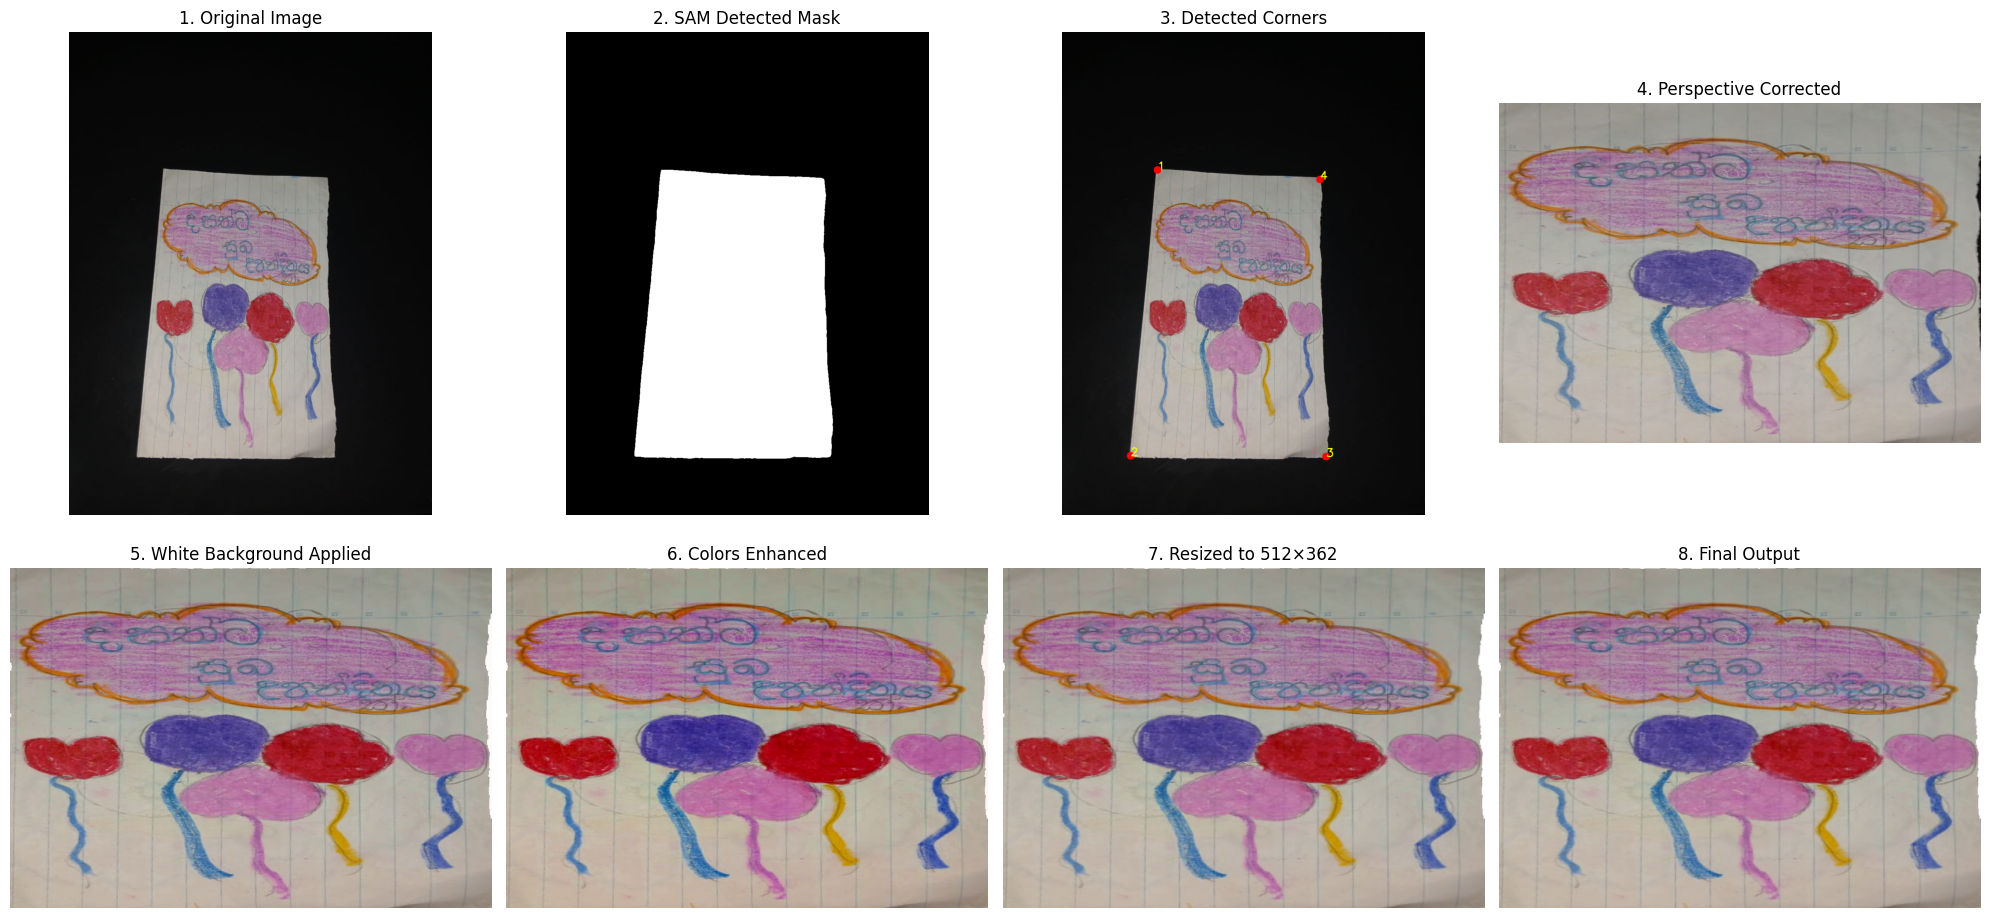


✅ PIPELINE COMPLETE!



In [4]:
detector = SAM_PaperDetector(model_type='vit_b')

final = full_pipeline_sam(
    image_path="../data/without line.jpeg",
    detector=detector,
    debug=True,              # See all steps
    save_path="../data/output/output.png",
    add_texture=False,       # True if dataset has crayon texture
    target_width=512,
    target_height=362
)